# CSE3CI Lab 6A: Introduction to TensorFlow 2.x & Regression with TensorFlow

## Introduction

In previous lectures and labs, many of you have learned how to program with Python and built intelligent systems. In this lab, we will start to learn the most popular framework for neural networks from Google -- TensorFlow 2.x.

In this lab, you will learn:
- How to build simple neural network models for regression tasks (6A).
- How to build simple neural network models for classification tasks (6B).

Note: TensorFlow is a tool for machine learning. While it contains a wide range of functionality, TensorFlow is mainly designed for deep neural network models. You are suggested to read the tutorials from the [website](https://www.tensorflow.org/tutorials/).

In [45]:
import tensorflow as tf

# Test TensorFlow installation
hello = tf.constant("Hello, TensorFlow!")
print(hello.numpy().decode('utf-8'))
print(f"TensorFlow version: {tf.__version__}")

Hello, TensorFlow!
TensorFlow version: 2.19.0


Note: You may see some informational messages when first importing TensorFlow - these are normal and can be ignored.

If the system outputs something like the following, then you are ready to begin writing TensorFlow programs:
```
Hello, TensorFlow!
TensorFlow version: 2.x.x
```

## Programming with TensorFlow

### Understanding Tensors

The central unit of data in TensorFlow is the **tensor**. A tensor consists of a set of primitive values shaped into an array of any number of dimensions. A tensor's **rank** is its number of dimensions, while its **shape** is a tuple of integers specifying the array's length along each dimension.

Here are some examples of tensor values:
```
3.                                     # rank 0 tensor (scalar), shape []
[1., 2., 3.]                          # rank 1 tensor (vector), shape [3]
[[1., 2., 3.], [4., 5., 6.]]          # rank 2 tensor (matrix), shape [2, 3]
[[[1., 2., 3.]], [[7., 8., 9.]]]      # rank 3 tensor, shape [2, 1, 3]
```

TensorFlow uses numpy arrays to represent tensor values. Let's start by creating a simple dataset:

### Simple Linear Regression Task

In [46]:
import tensorflow as tf
import numpy as np

# Create synthetic training data
# x_data: 100 random numbers between 0 and 1
x_data = np.random.rand(100).astype(np.float32)
# y_data: linear relationship y = 0.1*x + 0.3 (with noise implicitly)
y_data = x_data * 0.1 + 0.3

print(f"Data shapes - x_data: {x_data.shape}, y_data: {y_data.shape}")
print(f"Sample data - x: {x_data[:5]}, y: {y_data[:5]}")

Data shapes - x_data: (100,), y_data: (100,)
Sample data - x: [0.8071052  0.38786066 0.86354184 0.74712163 0.55624026], y: [0.38071054 0.33878607 0.3863542  0.37471217 0.35562405]


Now let's build a simple linear model to approximate our dataset. Our goal is to learn the relationship `y = Weights * x + biases` where the true relationship is `y = 0.1 * x + 0.3`.

So our learning task is to discover that:
- `Weights` should be approximately `0.1`
- `biases` should be approximately `0.3`

In TensorFlow, we use `tf.Variable` to create trainable parameters. Variables represent tensors whose values can be changed during training. Let's create our model parameters:

In [47]:
import tensorflow as tf

# Create trainable variables (model parameters)
Weights = tf.Variable(tf.random.uniform([1], -1.0, 1.0), name='weights')
biases = tf.Variable(tf.zeros([1]), name='biases')

print(f"Initial weights: {Weights.numpy()}")
print(f"Initial biases: {biases.numpy()}")

# Define our linear model
def model(x):
    return Weights * x + biases

Initial weights: [0.6585548]
Initial biases: [0.]


Next, we need to define a **loss function** to measure how well our model is performing. For regression tasks, we commonly use **Mean Squared Error (MSE)**:

**MSE = (1/n) × Σ(y_predicted - y_actual)²**

Where:
- `y_predicted` are our model's predictions
- `y_actual` are the true target values
- `n` is the number of samples

In TensorFlow, we can compute this using `tf.reduce_mean(tf.square(y_pred - y_true))`. The function `tf.reduce_mean` computes the mean of elements across dimensions of an input tensor.

Now we need to set up an **optimizer** to update our model parameters. We'll use **Stochastic Gradient Descent (SGD)** with a learning rate of 0.5:

In [48]:
# Set up the optimizer
optimizer = tf.optimizers.SGD(learning_rate=0.5)
print(f"Optimizer: {optimizer.__class__.__name__} with learning rate: {optimizer.learning_rate.numpy()}")

Optimizer: SGD with learning rate: 0.5


### Training the Model

Now we have all the components needed for training:
1. **Model**: Linear function with trainable parameters
2. **Loss function**: Mean Squared Error
3. **Optimizer**: SGD with learning rate 0.5

In TensorFlow 2.x, we use `tf.GradientTape()` to automatically compute gradients. The training process involves:

In [49]:
# Training loop
print("Starting training...")
for step in range(501):
    # Use GradientTape to record operations for automatic differentiation
    with tf.GradientTape() as tape:
        # Forward pass: compute predictions
        y_pred = model(x_data)
        # Compute loss (Mean Squared Error)
        loss = tf.reduce_mean(tf.square(y_pred - y_data))

    # Compute gradients of loss with respect to model parameters
    gradients = tape.gradient(loss, [Weights, biases])

    # Apply gradients to update parameters
    optimizer.apply_gradients(zip(gradients, [Weights, biases]))

    # Print progress every 50 steps
    if step % 50 == 0:
        print(f"Step {step:3d}: Loss = {loss.numpy():.6f}, "
              f"Weights = {Weights.numpy()[0]:.6f}, "
              f"Biases = {biases.numpy()[0]:.6f}")

print("Training completed!")

Starting training...
Step   0: Loss = 0.029361, Weights = 0.615810, Biases = 0.018286
Step  50: Loss = 0.000015, Weights = 0.111661, Biases = 0.293656
Step 100: Loss = 0.000000, Weights = 0.100263, Biases = 0.299857
Step 150: Loss = 0.000000, Weights = 0.100006, Biases = 0.299997
Step 200: Loss = 0.000000, Weights = 0.100000, Biases = 0.300000
Step 250: Loss = 0.000000, Weights = 0.100000, Biases = 0.300000
Step 300: Loss = 0.000000, Weights = 0.100000, Biases = 0.300000
Step 350: Loss = 0.000000, Weights = 0.100000, Biases = 0.300000
Step 400: Loss = 0.000000, Weights = 0.100000, Biases = 0.300000
Step 450: Loss = 0.000000, Weights = 0.100000, Biases = 0.300000
Step 500: Loss = 0.000000, Weights = 0.100000, Biases = 0.300000
Training completed!


### Results Analysis

You will find that the results match our expectations:
- `Weights` converges close to 0.1
- `Biases` converges close to 0.3
- The training loss (MSE) becomes very small, approaching zero

This shows that our model successfully learned the underlying linear relationship in the data.

### Complete Code Example

Let's put everything together in a complete, self-contained example:

In [50]:
import tensorflow as tf
import numpy as np

# Step 1: Create training data
x_data = np.random.rand(100).astype(np.float32)
y_data = x_data * 0.1 + 0.3

# Step 2: Define model parameters (trainable variables)
Weights = tf.Variable(tf.random.uniform([1], -1.0, 1.0), name='weights')
biases = tf.Variable(tf.zeros([1]), name='biases')

# Step 3: Define the model
def model(x):
    return Weights * x + biases

# Step 4: Set up optimizer
optimizer = tf.optimizers.SGD(learning_rate=0.5)

# Step 5: Training loop
for step in range(501):
    with tf.GradientTape() as tape:
        # Forward pass
        y_pred = model(x_data)
        # Compute loss
        loss = tf.reduce_mean(tf.square(y_pred - y_data))

    # Compute and apply gradients
    gradients = tape.gradient(loss, [Weights, biases])
    optimizer.apply_gradients(zip(gradients, [Weights, biases]))

    # Print progress
    if step % 100 == 0:
        print(f"Step {step}: Loss = {loss.numpy():.6f}, "
              f"W = {Weights.numpy()[0]:.4f}, b = {biases.numpy()[0]:.4f}")

print(f"Final results: W = {Weights.numpy()[0]:.4f}, b = {biases.numpy()[0]:.4f}")

Step 0: Loss = 0.420254, W = -0.1566, b = 0.6264
Step 100: Loss = 0.000000, W = 0.0988, b = 0.3006
Step 200: Loss = 0.000000, W = 0.1000, b = 0.3000
Step 300: Loss = 0.000000, W = 0.1000, b = 0.3000
Step 400: Loss = 0.000000, W = 0.1000, b = 0.3000
Step 500: Loss = 0.000000, W = 0.1000, b = 0.3000
Final results: W = 0.1000, b = 0.3000


## Advanced TensorFlow Concepts

In the previous section, we learned the basic structure of TensorFlow programs. Now let's explore some important concepts that will help you build more complex models.

### Matrix Operations

TensorFlow performs operations on tensors immediately. Here's how to work with matrices:

In [51]:
import tensorflow as tf

# Create two matrices
matrix1 = tf.constant([[2, 2]])  # shape: (1, 2)
matrix2 = tf.constant([[3], [3]])  # shape: (2, 1)

# Perform matrix multiplication
result = tf.matmul(matrix1, matrix2)

print(f"Matrix 1 shape: {matrix1.shape}")
print(f"Matrix 2 shape: {matrix2.shape}")
print(f"Result: {result.numpy()}")
print(f"Result shape: {result.shape}")

Matrix 1 shape: (1, 2)
Matrix 2 shape: (2, 1)
Result: [[12]]
Result shape: (1, 1)


### Working with Variables

Variables are the best way to represent shared, persistent state in your program. Unlike constants, variables can be modified during execution:

In [52]:
import tensorflow as tf

# Create a variable
counter = tf.Variable(0, name='counter')
print(f"Initial value: {counter.numpy()}")

# Update the variable using different methods
for i in range(3):
    counter.assign_add(1)  # equivalent to counter = counter + 1
    print(f"After step {i+1}: {counter.numpy()}")

# You can also assign a completely new value
counter.assign(10)
print(f"After assign(10): {counter.numpy()}")

# Variables maintain their state across operations
print(f"Variable name: {counter.name}")
print(f"Variable dtype: {counter.dtype}")
print(f"Variable shape: {counter.shape}")

Initial value: 0
After step 1: 1
After step 2: 2
After step 3: 3
After assign(10): 10
Variable name: counter:0
Variable dtype: <dtype: 'int32'>
Variable shape: ()


### Creating Functions

In TensorFlow 2.x, you can write functions naturally using Python. For performance optimization with large models, you can use `tf.function` decorator:

In [53]:
import tensorflow as tf

# Regular Python functions work with TensorFlow tensors
def add_operation(x, y):
    return x + y

def matrix_operation(x, y):
    return tf.matmul(x, y)

# Test with tensors
result1 = add_operation(tf.constant(5.0), tf.constant(3.0))
print(f"Addition result: {result1.numpy()}")

# Matrix multiplication example
x = tf.constant([[2.0], [2.0]])
y = tf.constant([[3.0, 3.0]])
result2 = matrix_operation(x, y)
print(f"Matrix multiplication result:\n{result2.numpy()}")

# Using tf.function for performance optimization (optional)
@tf.function
def optimized_add(x, y):
    return tf.add(x, y)

result3 = optimized_add(tf.constant(10.0), tf.constant(20.0))
print(f"Optimized addition result: {result3.numpy()}")

Addition result: 8.0
Matrix multiplication result:
[[6. 6.]
 [6. 6.]]
Optimized addition result: 30.0


### Activation Functions

**Activation functions** introduce non-linearity to neural networks, enabling them to learn complex patterns. Without activation functions, neural networks would only be able to learn linear relationships.

TensorFlow provides various activation functions:
- **Smooth functions**: sigmoid, tanh, elu, softplus, and softmax
- **Non-smooth functions**: relu, relu6, crelu and relu_x
- **Regularization**: dropout

Let's visualize some popular activation functions to understand their behavior. See the full [documentation](https://www.tensorflow.org/api_docs/python/tf/nn) for more details.

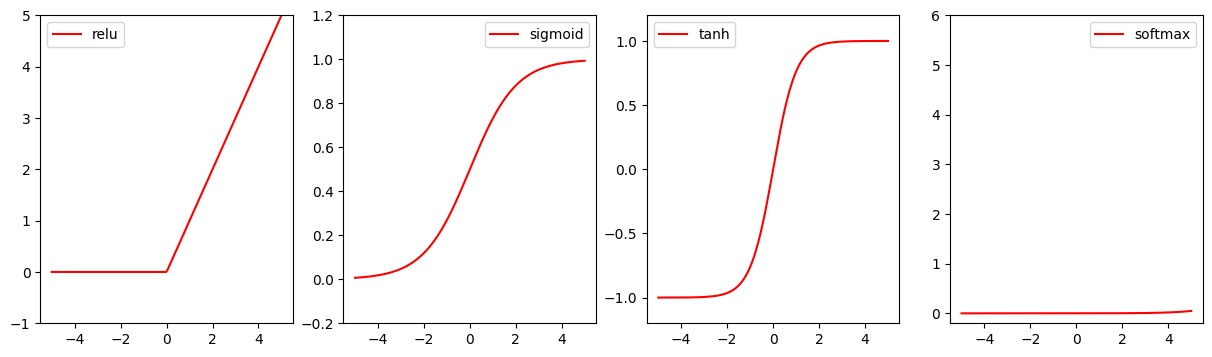

In [54]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Create sample data points
x = np.linspace(-5, 5, 200)     # 200 evenly spaced numbers between -5 and 5

# Apply different activation functions - TensorFlow 2.x executes immediately
y_relu = tf.nn.relu(x)          # ReLU: max(0, x)
y_sigmoid = tf.nn.sigmoid(x)    # Sigmoid: 1/(1+e^(-x))
y_tanh = tf.nn.tanh(x)          # Tanh: (e^x - e^(-x))/(e^x + e^(-x))
y_softmax = tf.nn.softmax(x)    # Softmax: probability distribution

# Convert to numpy for plotting (automatic in TF 2.x)
y_relu = y_relu.numpy()
y_sigmoid = y_sigmoid.numpy()
y_tanh = y_tanh.numpy()
y_softmax = y_softmax.numpy()

# Visualize the activation functions
plt.figure(1, figsize=(15, 4))
plt.subplot(141)
plt.plot(x, y_relu, c='red', label='relu')
plt.ylim((-1, 5))
plt.legend(loc='best')

plt.subplot(142)
plt.plot(x, y_sigmoid, c='red', label='sigmoid')
plt.ylim((-0.2, 1.2))
plt.legend(loc='best')

plt.subplot(143)
plt.plot(x, y_tanh, c='red', label='tanh')
plt.ylim((-1.2, 1.2))
plt.legend(loc='best')

plt.subplot(144)
plt.plot(x, y_softmax, c='red', label='softmax')
plt.ylim((-0.2, 6))
plt.legend(loc='best')

plt.show()

## Neural Network Regression

Now let's build a more complex model - a neural network with hidden layers to solve a non-linear regression problem:

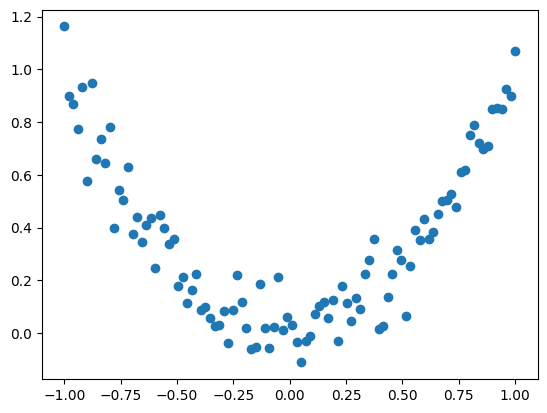

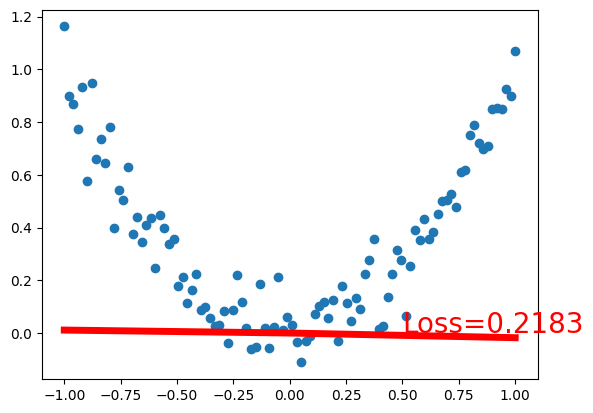

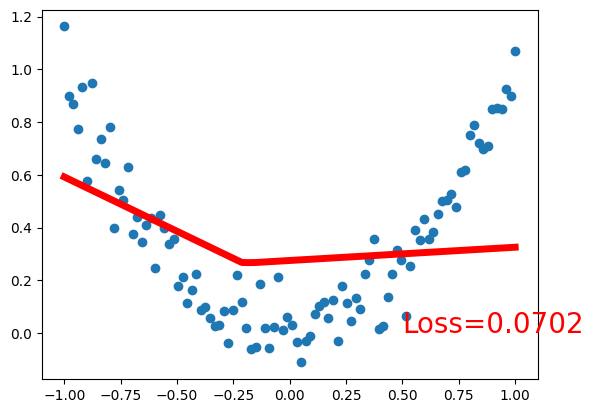

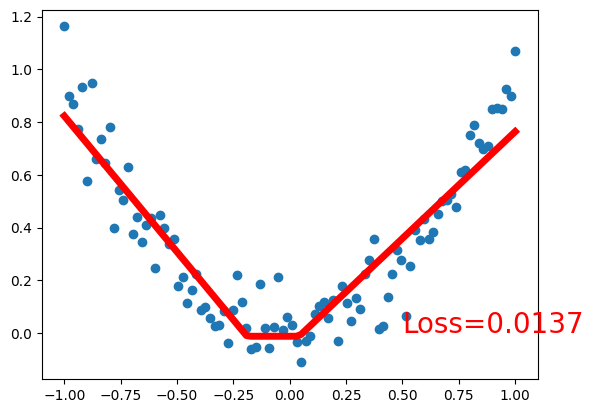

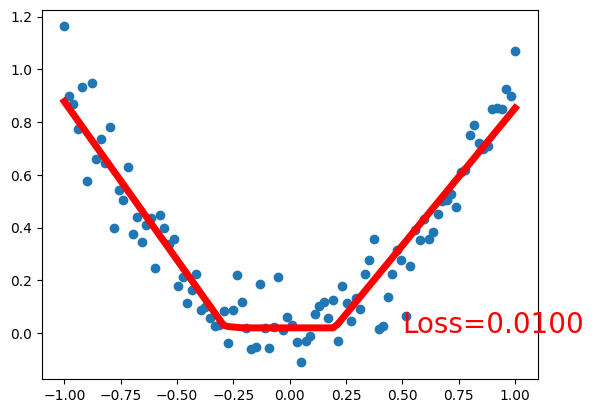

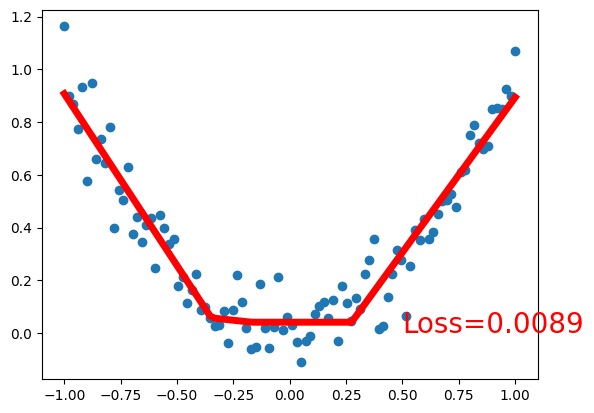

In [55]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

tf.random.set_seed(1)
np.random.seed(1)

# fake data - ensure float32 type
x = np.linspace(-1, 1, 100)[:, np.newaxis].astype(np.float32)          # shape (100, 1)
noise = np.random.normal(0, 0.1, size=x.shape).astype(np.float32)
y = np.power(x, 2) + noise                                             # shape (100, 1) + some noise

# plot data
plt.scatter(x, y)
plt.show()

# Define variables for the neural network
W1 = tf.Variable(tf.random.normal([1, 10], stddev=0.1, dtype=tf.float32), name='W1')
b1 = tf.Variable(tf.zeros([10], dtype=tf.float32), name='b1')
W2 = tf.Variable(tf.random.normal([10, 1], stddev=0.1, dtype=tf.float32), name='W2')
b2 = tf.Variable(tf.zeros([1], dtype=tf.float32), name='b2')

def neural_network(x_input):
    """Define the neural network forward pass"""
    layer1 = tf.nn.relu(tf.matmul(x_input, W1) + b1)  # hidden layer with ReLU
    output = tf.matmul(layer1, W2) + b2                # output layer
    return output

def loss_function(y_true, y_pred):
    """Calculate mean squared error loss"""
    return tf.reduce_mean(tf.square(y_true - y_pred))

# Optimizer
optimizer = tf.optimizers.SGD(learning_rate=0.5)

plt.ion()   # interactive mode

for step in range(201):
    with tf.GradientTape() as tape:
        # Forward pass
        pred = neural_network(x)
        loss = loss_function(y, pred)

    # Compute gradients and update weights
    gradients = tape.gradient(loss, [W1, b1, W2, b2])
    optimizer.apply_gradients(zip(gradients, [W1, b1, W2, b2]))

    if step % 50 == 0:
        # plot and show learning process
        plt.cla()
        plt.scatter(x, y)
        plt.plot(x, pred.numpy(), 'r-', lw=5)
        plt.text(0.5, 0, 'Loss=%.4f' % loss.numpy(), fontdict={'size': 20, 'color': 'red'})
        plt.pause(0.1)

plt.ioff() # back to the block mode

## Summary

In this lab, you have learned:

### Key Concepts
1. **Tensors**: Multi-dimensional arrays that are the fundamental data structure in TensorFlow
2. **Variables**: Trainable parameters that maintain state and can be updated during training  
3. **GradientTape**: TensorFlow's automatic differentiation system for computing gradients
4. **Optimizers**: Algorithms (like SGD) that update model parameters based on gradients

### Two Types of Regression Models
1. **Linear Regression**: Simple model with `y = Wx + b` for linear relationships
2. **Neural Network Regression**: Multi-layer model with non-linear activation functions for complex relationships

### The Training Process
1. **Forward Pass**: Compute predictions using current parameters
2. **Loss Calculation**: Measure how far predictions are from true values  
3. **Gradient Computation**: Calculate how to adjust parameters to reduce loss
4. **Parameter Update**: Apply gradients using an optimizer

### TensorFlow 2.x Advantages
- **Intuitive API**: Write code that looks like regular Python
- **Automatic Differentiation**: No need to manually compute gradients
- **Flexible Architecture**: Easy to build from simple linear models to complex neural networks

This foundation will help you tackle more complex machine learning problems in future labs!